# Loading the dataset

In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords

# Load dataset
file_path = "tripadvisor_hotel_reviews.csv"  # Make sure the file is in the working directory
df = pd.read_csv(file_path)

# Display basic dataset information

In [ ]:
# Display basic dataset info
print("Dataset Info:")
print(df.info())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20491 entries, 0 to 20490
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  20491 non-null  object
 1   Rating  20491 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 320.3+ KB
None


# Data cleaning

In [ ]:
# Step 1: Data Cleaning
df.drop_duplicates(inplace=True)  # Remove duplicate reviews
df.dropna(inplace=True)  # Remove missing values

# Convert text to lowercase
df['Cleaned_Review'] = df['Review'].str.lower()

In [ ]:
# Step 2: Data Wrangling
# Create a new column with review length
df['Review_Length'] = df['Cleaned_Review'].apply(lambda x: len(x.split()))

# Remove stopwords
stop_words = set(stopwords.words('english'))
df['Cleaned_Review'] = df['Cleaned_Review'].apply(lambda x: " ".join([word for word in x.split() if word not in stop_words]))

# Display the distribution of Review Lenghts

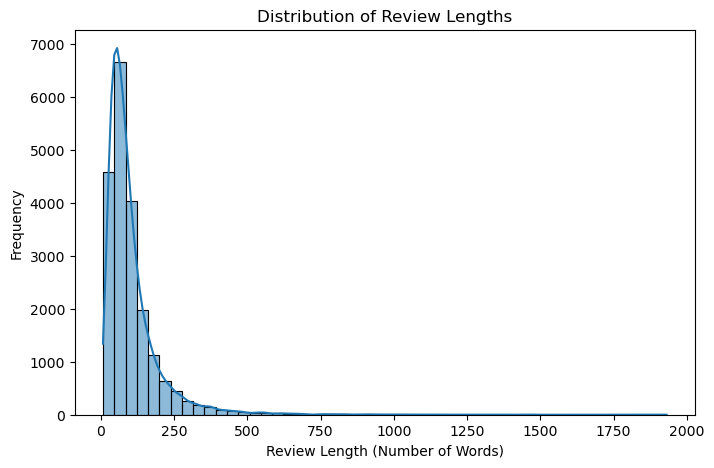

In [ ]:
# Step 3: Data Exploration - Distribution of Review Lengths
plt.figure(figsize=(8,5))
sns.histplot(df['Review_Length'], bins=50, kde=True)
plt.title("Distribution of Review Lengths")
plt.xlabel("Review Length (Number of Words)")
plt.ylabel("Frequency")
plt.show()

In [ ]:
# Show the first 5 rows of the processed data
print("\nProcessed Data Preview:")
print(df.head())


Processed Data Preview:
                                              Review  Rating  \
0  nice hotel expensive parking got good deal sta...       4   
1  ok nothing special charge diamond member hilto...       2   
2  nice rooms not 4* experience hotel monaco seat...       3   
3  unique, great stay, wonderful time hotel monac...       5   
4  great stay great stay, went seahawk game aweso...       5   

                                      Cleaned_Review  Review_Length  
0  nice hotel expensive parking got good deal sta...             87  
1  ok nothing special charge diamond member hilto...            250  
2  nice rooms 4* experience hotel monaco seattle ...            217  
3  unique, great stay, wonderful time hotel monac...             89  
4  great stay great stay, went seahawk game aweso...            191  


# Display basic statistics for review lengths

In [ ]:
# Display basic statistics for review lengths
df.describe()['Review_Length']

count    20491.000000
mean       104.375824
std        100.656586
min          7.000000
25%         48.000000
50%         77.000000
75%        124.000000
max       1931.000000
Name: Review_Length, dtype: float64

In [ ]:
# Further data preparation for topic modeling and sentiment analysis

from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Download necessary NLTK data
nltk.download('wordnet')
nltk.download('omw-1.4')

# Initialize lemmatizer
lemmatizer = WordNetLemmatizer()

# Lemmatize the cleaned reviews
df['Lemmatized_Review'] = df['Cleaned_Review'].apply(lambda x: " ".join([lemmatizer.lemmatize(word) for word in x.split()]))


# Function to analyze sentiment using VADER
analyzer = SentimentIntensityAnalyzer()
def get_sentiment(text):
    scores = analyzer.polarity_scores(text)
    return scores['compound']

# Add sentiment scores to the DataFrame
df['Sentiment_Score'] = df['Lemmatized_Review'].apply(get_sentiment)


# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(df['Lemmatized_Review'], df['Sentiment_Score'], test_size=0.2, random_state=42)

print("\nData Split Preview:")
print("Train Size:", len(X_train))
print("Test Size:", len(X_test))

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/xiaohui_lu/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/xiaohui_lu/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!



Data Split Preview:
Train Size: 16392
Test Size: 4099


In [ ]:
# Further data preparation (example: removing punctuation and special characters)
def preprocess_text(text):
    text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation
    return text

df['Processed_Review'] = df['Lemmatized_Review'].apply(preprocess_text)

# Example:  Splitting the data into train, validation, and test sets
X = df['Processed_Review']
y = df['Sentiment_Score']

X_train, X_rem, y_train, y_rem = train_test_split(X, y, train_size=0.8, random_state=42)
X_valid, X_test, y_valid, y_test = train_test_split(X_rem, y_rem, test_size=0.5, random_state=42)

print("\nData Split (Train/Validation/Test) Preview:")
print("Train Size:", len(X_train))
print("Validation Size:", len(X_valid))
print("Test Size:", len(X_test))



Data Split (Train/Validation/Test) Preview:
Train Size: 16392
Validation Size: 2049
Test Size: 2050


In [ ]:
# prompt: Feature engineering: Create numerical features from the text data for use in various classification models. This could include TF-IDF or word embeddings.

from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000)  # Adjust max_features as needed

# Fit and transform the training data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# Transform the validation and test data
X_valid_tfidf = tfidf_vectorizer.transform(X_valid)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("\nTF-IDF Feature Shapes:")
print("Train:", X_train_tfidf.shape)
print("Validation:", X_valid_tfidf.shape)
print("Test:", X_test_tfidf.shape)



TF-IDF Feature Shapes:
Train: (16392, 5000)
Validation: (2049, 5000)
Test: (2050, 5000)


In [ ]:
# The data is already split into training, validation, and testing sets in the provided code.
# X_train, X_valid, X_test, y_train, y_valid, y_test are already defined.

# Example usage of the splits (you can replace this with your model training code)
print("Training data shape:", X_train.shape)
print("Validation data shape:", X_valid.shape)
print("Test data shape:", X_test.shape)

Training data shape: (16392,)
Validation data shape: (2049,)
Test data shape: (2050,)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
# Import the necessary library for converting continuous to discrete values
from sklearn.preprocessing import LabelBinarizer

# Initialize the models
logreg_model = LogisticRegression(max_iter=1000)  # Increased max_iter for convergence
svm_model = LinearSVC()
nb_model = MultinomialNB()
rf_model = RandomForestClassifier()

# Convert the continuous sentiment scores to discrete classes for classification
# Assuming sentiment scores above 0 are positive, below 0 are negative, and 0 is neutral
y_train_discrete = pd.cut(y_train, bins=[-1, 0, 0.0001, 1], labels=[-1, 0, 1], include_lowest=True, duplicates='drop')
y_valid_discrete = pd.cut(y_valid, bins=[-1, 0, 0.0001, 1], labels=[-1, 0, 1], include_lowest=True, duplicates='drop')
# Convert the discrete labels to numerical using LabelBinarizer
lb = LabelBinarizer()
y_train_discrete = lb.fit_transform(y_train_discrete)
y_valid_discrete = lb.transform(y_valid_discrete)
# Train the models using the discrete target variables
logreg_model.fit(X_train_tfidf, y_train_discrete)
svm_model.fit(X_train_tfidf, y_train_discrete)
nb_model.fit(X_train_tfidf, y_train_discrete)
rf_model.fit(X_train_tfidf, y_train_discrete)

# Make predictions on the validation set
logreg_pred = logreg_model.predict(X_valid_tfidf)
svm_pred = svm_model.predict(X_valid_tfidf)
nb_pred = nb_model.predict(X_valid_tfidf)
rf_pred = rf_model.predict(X_valid_tfidf)

# Evaluate the models using the discrete target variables
print("Logistic Regression:")
print("Accuracy:", accuracy_score(y_valid_discrete, logreg_pred))
print(classification_report(y_valid_discrete, logreg_pred))

print("\nSupport Vector Machine:")
print("Accuracy:", accuracy_score(y_valid_discrete, svm_pred))
print(classification_report(y_valid_discrete, svm_pred))

print("\nNaive Bayes:")
print("Accuracy:", accuracy_score(y_valid_discrete, nb_pred))
print(classification_report(y_valid_discrete, nb_pred))

print("\nRandom Forest:")
print("Accuracy:", accuracy_score(y_valid_discrete, rf_pred))
print(classification_report(y_valid_discrete, rf_pred))

/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for e

Logistic Regression:
Accuracy: 0.9633967789165446
              precision    recall  f1-score   support

           0       0.97      0.33      0.49       110
           1       0.96      1.00      0.98      1939

    accuracy                           0.96      2049
   macro avg       0.97      0.66      0.74      2049
weighted avg       0.96      0.96      0.95      2049


Support Vector Machine:
Accuracy: 0.9692532942898975
              precision    recall  f1-score   support

           0       0.81      0.55      0.66       110
           1       0.98      0.99      0.98      1939

    accuracy                           0.97      2049
   macro avg       0.89      0.77      0.82      2049
weighted avg       0.97      0.97      0.97      2049


Naive Bayes:
Accuracy: 0.9487554904831625
              precision    recall  f1-score   support

           0       0.86      0.05      0.10       110
           1       0.95      1.00      0.97      1939

    accuracy                       

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelBinarizer

# Convert the continuous sentiment scores to discrete classes for classification
# Assuming sentiment scores above 0 are positive, below 0 are negative, and 0 is neutral
y_test_discrete = pd.cut(y_test, bins=[-1, 0, 0.0001, 1], labels=[-1, 0, 1], include_lowest=True, duplicates='drop')

# Convert the discrete labels to numerical using LabelBinarizer
lb = LabelBinarizer()
y_test_discrete = lb.fit_transform(y_test_discrete)

# Make predictions on the test set
logreg_pred_test = logreg_model.predict(X_test_tfidf)
svm_pred_test = svm_model.predict(X_test_tfidf)
nb_pred_test = nb_model.predict(X_test_tfidf)
rf_pred_test = rf_model.predict(X_test_tfidf)


def evaluate_model(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    # AUC requires probability scores, not just class predictions
    # Assuming your models can output probabilities (e.g., using predict_proba)
    # If not, you will need to adapt this part or remove AUC calculation
    # y_pred_prob = model.predict_proba(X_test)[:, 1]
    # auc = roc_auc_score(y_test, y_pred_prob)

    return accuracy, precision, recall, f1


# Evaluate each model on the test set
models = {
    "Logistic Regression": (logreg_pred_test, y_test_discrete),
    "SVM": (svm_pred_test, y_test_discrete),
    "Naive Bayes": (nb_pred_test, y_test_discrete),
    "Random Forest": (rf_pred_test, y_test_discrete),
}

results = []

for model_name, (y_pred, y_true) in models.items():
  accuracy, precision, recall, f1 = evaluate_model(y_true, y_pred)
  results.append([model_name, accuracy, precision, recall, f1])

# Create a DataFrame for better visualization
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-score"])
print(results_df)

# Compare and choose the best model based on the metrics
best_model = results_df.loc[results_df['Accuracy'].idxmax()]
print(f"\nBest Model based on Accuracy:\n{best_model}")


                 Model  Accuracy  Precision    Recall  F1-score
0  Logistic Regression  0.958537   0.954270  0.958537  0.947743
1                  SVM  0.968293   0.965472  0.968293  0.966113
2          Naive Bayes  0.949268   0.935699  0.949268  0.928462
3        Random Forest  0.950732   0.953166  0.950732  0.929338

Best Model based on Accuracy:
Model             SVM
Accuracy     0.968293
Precision    0.965472
Recall       0.968293
F1-score     0.966113
Name: 1, dtype: object


/var/folders/qs/l35k3bl93fn745d94blb9gb40000gn/T/ipykernel_6911/1524470052.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="Accuracy", data=results_df, palette="viridis")


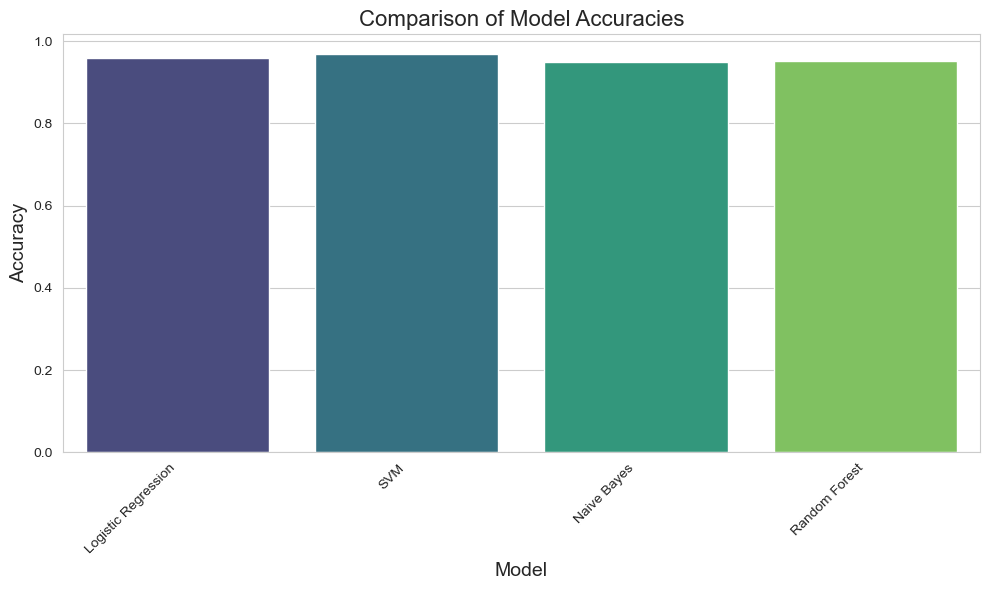

/var/folders/qs/l35k3bl93fn745d94blb9gb40000gn/T/ipykernel_6911/1524470052.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y=metric, data=results_df, palette="viridis")
/var/folders/qs/l35k3bl93fn745d94blb9gb40000gn/T/ipykernel_6911/1524470052.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y=metric, data=results_df, palette="viridis")
/var/folders/qs/l35k3bl93fn745d94blb9gb40000gn/T/ipykernel_6911/1524470052.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y=metric, data=results_df, palette="vi

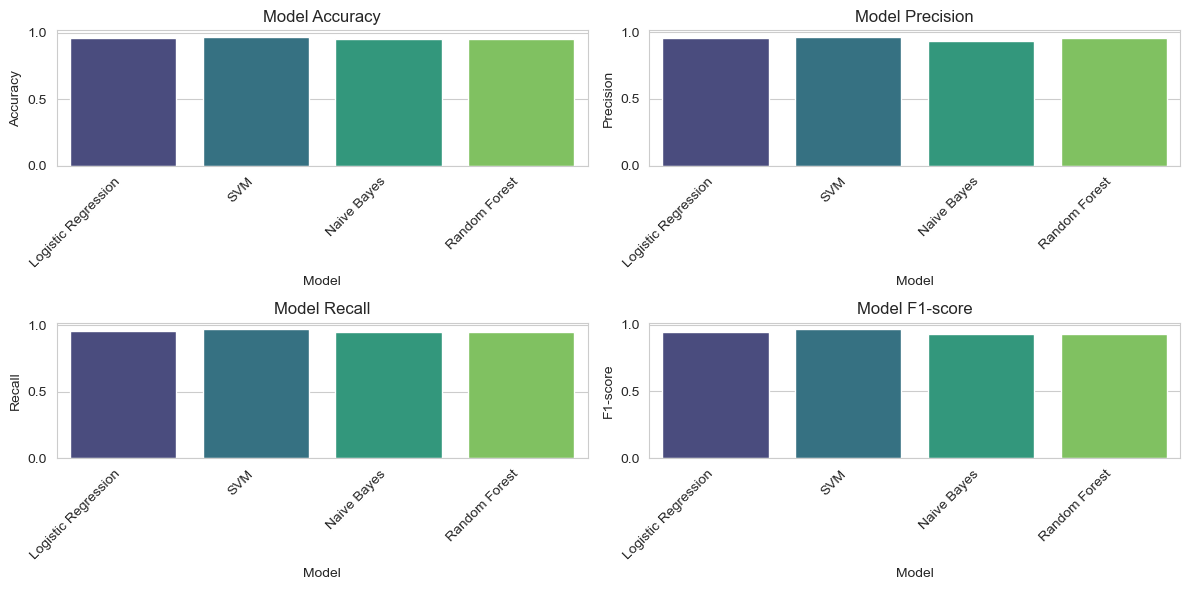

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming results_df is already created as in the previous code

# Set the style for the plot
sns.set_style("whitegrid")

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x="Model", y="Accuracy", data=results_df, palette="viridis")
plt.title("Comparison of Model Accuracies", fontsize=16)
plt.xlabel("Model", fontsize=14)
plt.ylabel("Accuracy", fontsize=14)
plt.xticks(rotation=45, ha="right")  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()


# Create a comparison plot for multiple metrics
plt.figure(figsize=(12, 6))
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
for i, metric in enumerate(metrics):
  plt.subplot(2, 2, i + 1)
  sns.barplot(x="Model", y=metric, data=results_df, palette="viridis")
  plt.title(f"Model {metric}", fontsize=12)
  plt.xlabel("Model")
  plt.ylabel(metric)
  plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


/var/folders/qs/l35k3bl93fn745d94blb9gb40000gn/T/ipykernel_6911/2115204845.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="Model", y=metric, data=results_df, palette="viridis")
/var/folders/qs/l35k3bl93fn745d94blb9gb40000gn/T/ipykernel_6911/2115204845.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="Model", y=metric, data=results_df, palette="viridis")
/var/folders/qs/l35k3bl93fn745d94blb9gb40000gn/T/ipykernel_6911/2115204845.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="Model", y=metric, data=results_df,

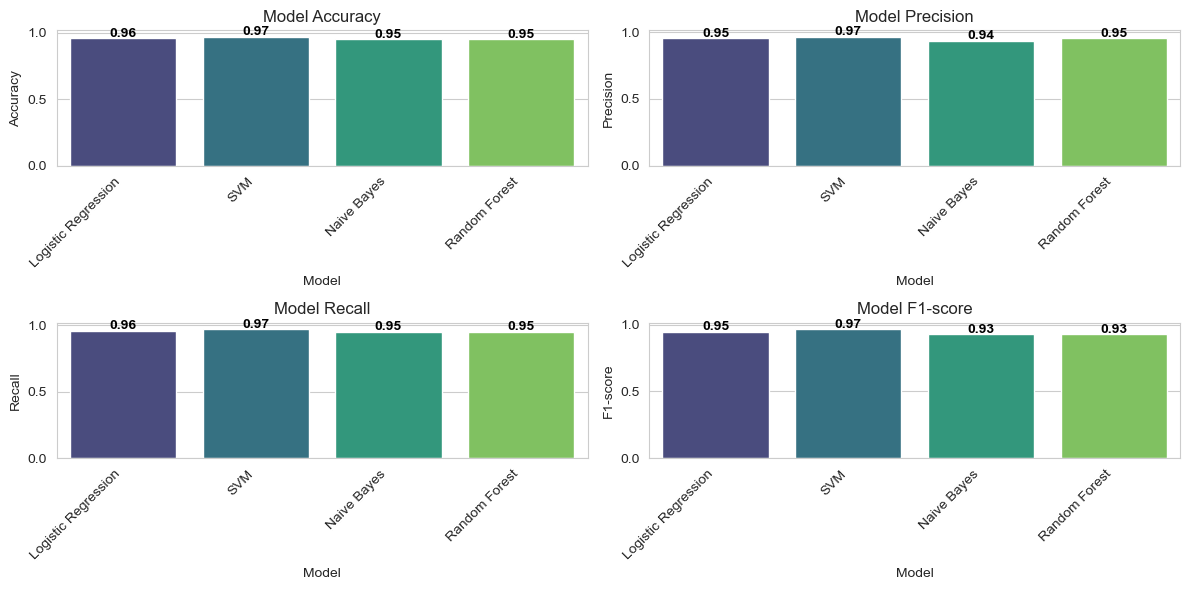

In [ ]:
plt.figure(figsize=(12, 6))
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]

for i, metric in enumerate(metrics):
    plt.subplot(2, 2, i + 1)
    ax = sns.barplot(x="Model", y=metric, data=results_df, palette="viridis")

    # Add text labels on bars
    for p in ax.patches:
        ax.text(p.get_x() + p.get_width() / 2,
                p.get_height() + 0.01,  # Adjust the position above the bar
                f'{p.get_height():.2f}',  # Format to 2 decimal places
                ha='center', fontsize=10, fontweight='bold', color='black')

    plt.title(f"Model {metric}", fontsize=12)
    plt.xlabel("Model")
    plt.ylabel(metric)
    plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

/var/folders/qs/l35k3bl93fn745d94blb9gb40000gn/T/ipykernel_6911/850755949.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="Model", y=metric, data=results_df, palette="viridis")


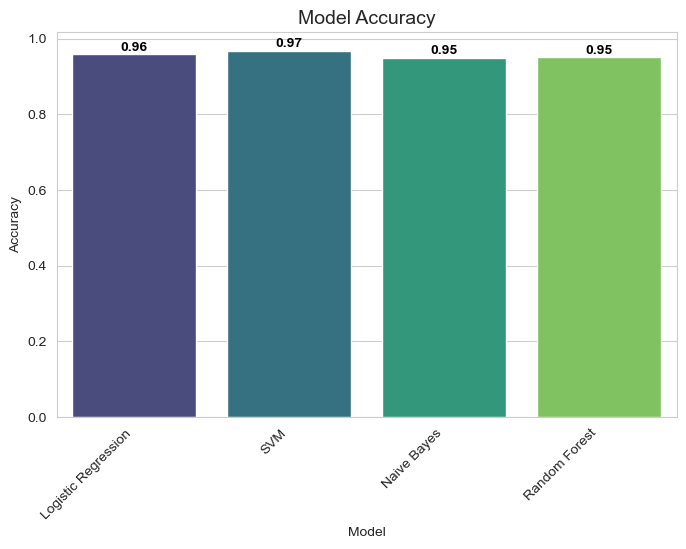

/var/folders/qs/l35k3bl93fn745d94blb9gb40000gn/T/ipykernel_6911/850755949.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="Model", y=metric, data=results_df, palette="viridis")


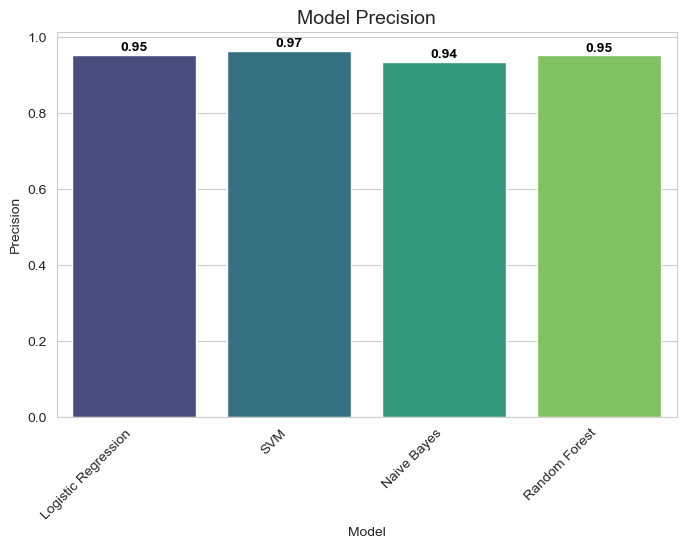

/var/folders/qs/l35k3bl93fn745d94blb9gb40000gn/T/ipykernel_6911/850755949.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="Model", y=metric, data=results_df, palette="viridis")


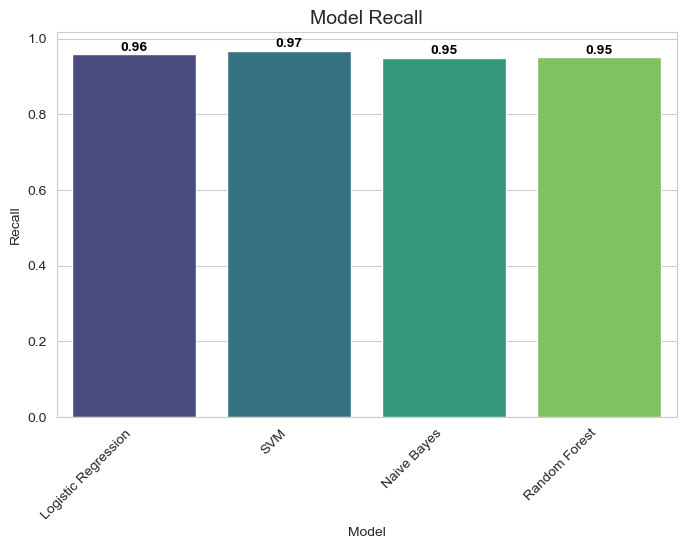

/var/folders/qs/l35k3bl93fn745d94blb9gb40000gn/T/ipykernel_6911/850755949.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="Model", y=metric, data=results_df, palette="viridis")


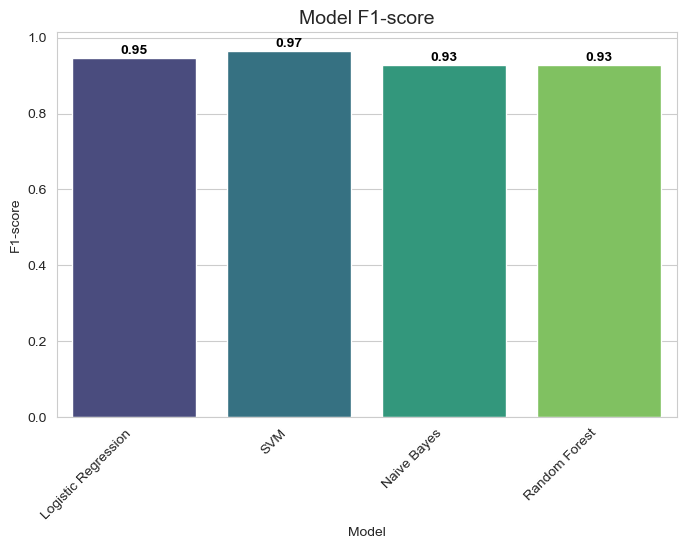

In [ ]:

metrics = ["Accuracy", "Precision", "Recall", "F1-score"]

for metric in metrics:
    plt.figure(figsize=(8, 5))  # Create a new figure for each metric
    ax = sns.barplot(x="Model", y=metric, data=results_df, palette="viridis")

    # Add text labels on bars
    for p in ax.patches:
        ax.text(p.get_x() + p.get_width() / 2,
                p.get_height() + 0.01,  # Adjust label position slightly above bars
                f'{p.get_height():.2f}',  # Format values to 2 decimal places
                ha='center', fontsize=10, fontweight='bold', color='black')

    # Titles and Labels
    plt.title(f"Model {metric}", fontsize=14)
    plt.xlabel("Model")
    plt.ylabel(metric)
    plt.xticks(rotation=45, ha="right")

    plt.show()  # Display each plot separately

In [ ]:
# Assuming 'best_model' is defined from the previous code block (e.g., logreg_model)
# and that 'df' contains the necessary columns like 'Lemmatized_Review', 'Sentiment_Score', etc.

# Convert sentiment scores to categories
def categorize_sentiment(score):
    if score > 0.05:
        return "positive"
    elif score < -0.05:
        return "negative"
    else:
        return "neutral"

df['Sentiment_Category'] = df['Sentiment_Score'].apply(categorize_sentiment)

# Get most frequent words per sentiment
from collections import Counter

def get_frequent_words(reviews, num_words=10):
    all_words = []
    for review in reviews:
      all_words.extend(review.split())
    return Counter(all_words).most_common(num_words)

for category in df['Sentiment_Category'].unique():
    category_reviews = df[df['Sentiment_Category'] == category]['Lemmatized_Review']
    frequent_words = get_frequent_words(category_reviews)
    print(f"\nMost Frequent Words for {category} Sentiment:")
    for word, count in frequent_words:
        print(f"{word}: {count}")



Most Frequent Words for positive Sentiment:
hotel: 43264
room: 39036
great: 18604
n't: 17364
good: 14568
staff: 14391
stay: 10874
nice: 10749
night: 10627
day: 9637

Most Frequent Words for negative Sentiment:
room: 2319
hotel: 2154
n't: 1020
stay: 607
staff: 597
night: 571
service: 557
day: 547
time: 449
stayed: 426

Most Frequent Words for neutral Sentiment:
hotel: 116
room: 112
n't: 52
stay: 39
time: 33
day: 27
location: 24
staff: 24
night: 23
got: 21


/var/folders/qs/l35k3bl93fn745d94blb9gb40000gn/T/ipykernel_6911/631680618.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Count', y='Word', data=words_df, palette='viridis')


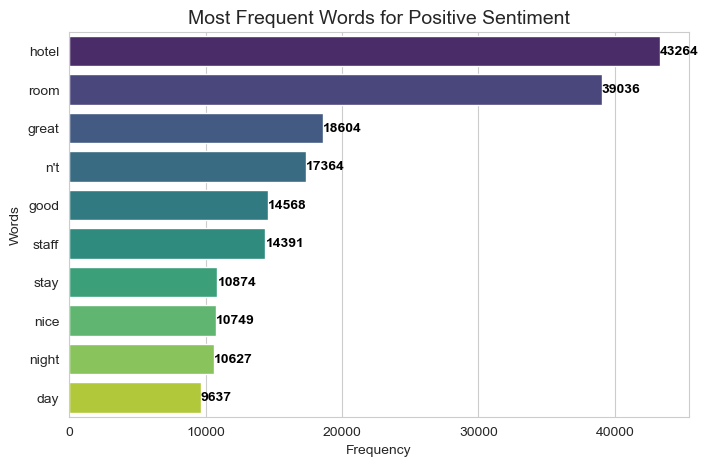

/var/folders/qs/l35k3bl93fn745d94blb9gb40000gn/T/ipykernel_6911/631680618.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Count', y='Word', data=words_df, palette='viridis')


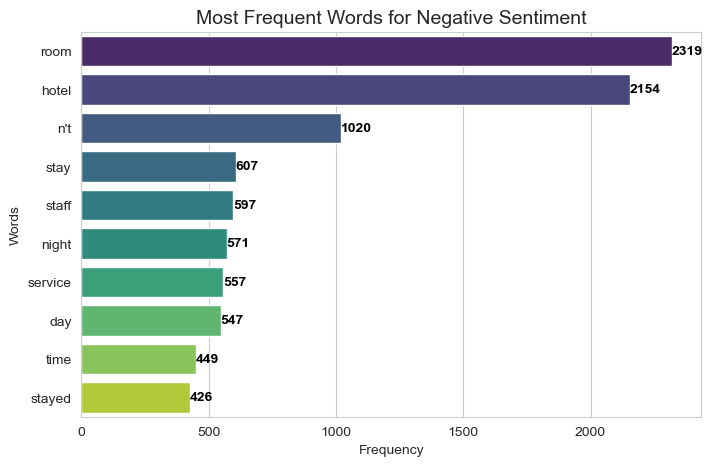

/var/folders/qs/l35k3bl93fn745d94blb9gb40000gn/T/ipykernel_6911/631680618.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Count', y='Word', data=words_df, palette='viridis')


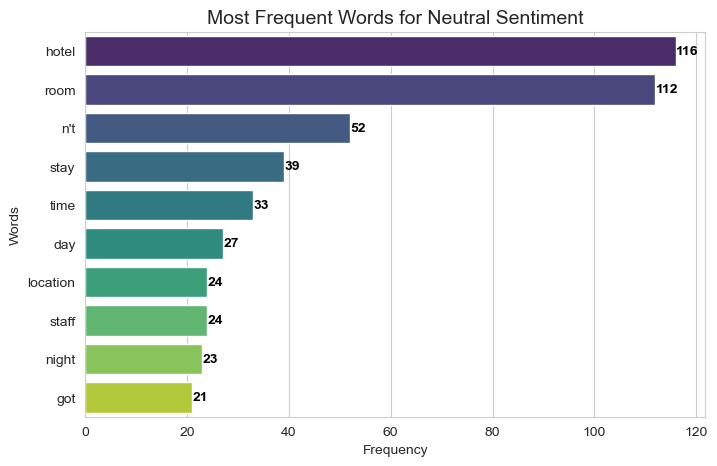

In [ ]:

# Function to categorize sentiment
def categorize_sentiment(score):
    if score > 0.05:
        return "positive"
    elif score < -0.05:
        return "negative"
    else:
        return "neutral"

df['Sentiment_Category'] = df['Sentiment_Score'].apply(categorize_sentiment)

# Function to get most frequent words
def get_frequent_words(reviews, num_words=10):
    all_words = []
    for review in reviews:
        all_words.extend(review.split())  # Split words and add to list
    return Counter(all_words).most_common(num_words)

# Define sentiment categories
sentiment_categories = ["positive", "negative", "neutral"]

# Generate separate plots for each sentiment category
for category in sentiment_categories:
    category_reviews = df[df['Sentiment_Category'] == category]['Lemmatized_Review']
    frequent_words = get_frequent_words(category_reviews)

    # Convert to DataFrame for visualization
    words_df = pd.DataFrame(frequent_words, columns=['Word', 'Count'])

    # Create a new figure for each sentiment
    plt.figure(figsize=(8, 5))

    # Create barplot
    ax = sns.barplot(x='Count', y='Word', data=words_df, palette='viridis')

    # Add value labels on top of bars
    for p in ax.patches:
        ax.text(p.get_width() + 0.1,  # Adjust horizontal placement
                p.get_y() + p.get_height() / 2,  # Center vertically
                f'{int(p.get_width())}',  # Display integer count
                ha='left', va='center', fontsize=10, fontweight='bold', color='black')

    # Titles and labels
    plt.title(f"Most Frequent Words for {category.capitalize()} Sentiment", fontsize=14)
    plt.xlabel("Frequency")
    plt.ylabel("Words")

    # Show each plot separately
    plt.show()

In [ ]:
from sklearn.decomposition import LatentDirichletAllocation

# Assuming 'best_model' is your chosen model (e.g., Logistic Regression)
# and X_train_tfidf is the TF-IDF representation of your training data.

# 1. Topic Modeling with LDA (using TF-IDF features)
num_topics = 10  # Adjust the number of topics as needed
lda_model = LatentDirichletAllocation(n_components=num_topics, random_state=42)
lda_model.fit(X_train_tfidf)

# Get topic-word distributions
topic_word_distributions = lda_model.components_

# Get the top words for each topic
n_top_words = 10  # Number of top words to display
feature_names = tfidf_vectorizer.get_feature_names_out()

for topic_idx, topic in enumerate(topic_word_distributions):
  top_words_idx = topic.argsort()[:-n_top_words - 1:-1]  # Get indices of top words
  top_words = [feature_names[i] for i in top_words_idx]
  print(f"Topic {topic_idx + 1}: {' '.join(top_words)}")


# 2.  Feature Engineering: Create Topic Distribution Features
# Transform the training data to get topic distributions
doc_topic_dists = lda_model.transform(X_train_tfidf)

# Create new features for each topic in the training data
# Get the indices of the training data in the original dataframe
train_indices = X_train.index

# Create a temporary dataframe for the training data with topic distributions
train_df = df.loc[train_indices]

# Add topic columns to the temporary dataframe
for i in range(num_topics):
    train_df[f'topic_{i+1}'] = doc_topic_dists[:, i]

# Merge the temporary dataframe with the original dataframe
df = pd.merge(df, train_df[[f'topic_{i+1}' for i in range(num_topics)]], how='left', left_index=True, right_index=True)

# Fill NaN values with 0 (for data points not in training set)
df[[f'topic_{i+1}' for i in range(num_topics)]] = df[[f'topic_{i+1}' for i in range(num_topics)]].fillna(0)

# Now you have new features 'topic_1', 'topic_2', ..., 'topic_10' representing the probability of each document belonging to each topic.
# These features will be 0 for data points not in the training set.

Topic 1: room hotel nt stay night told bed desk staff dirty
Topic 2: argonaut san francisco rex fran cable fisherman wharf milano chancellor
Topic 3: hotel room great location staff good breakfast stay clean excellent
Topic 4: hong kong harbour kowloon darling ferry mtr hk silla circular
Topic 5: mansion sooooo bank hype diner shoes adequate awesome horrendous array
Topic 6: adagio moore bungalow keeper practical de temp du unique moment
Topic 7: hotel room great stay location good nt nice staff service
Topic 8: resort beach food pool nt great time day good room
Topic 9: owl petite ic specially elan girls angeles los adults pig
Topic 10: hotel great location stay staff wonderful perfect room helpful stayed


In [ ]:
from sklearn.cluster import KMeans

# Assuming 'df' contains the topic distribution features (topic_1, topic_2, ..., topic_10)
# and 'Sentiment_Category' (positive, negative, neutral)

# Select features for clustering (topic distributions)
topic_features = [f'topic_{i+1}' for i in range(num_topics)]
X_cluster = df[topic_features]

# Determine optimal number of clusters (e.g., using the elbow method or silhouette analysis)
# For demonstration, we'll use 3 clusters (you should optimize this based on your data)
kmeans = KMeans(n_clusters=3, random_state=42)

# Fit the KMeans model
kmeans.fit(X_cluster)

# Add cluster labels to the DataFrame
df['Cluster_Label'] = kmeans.labels_

# Analyze clusters
for cluster_label in df['Cluster_Label'].unique():
    cluster_data = df[df['Cluster_Label'] == cluster_label]
    print(f"\nCluster {cluster_label}:")

    # Analyze sentiment distribution in the cluster
    sentiment_counts = cluster_data['Sentiment_Category'].value_counts()
    print("Sentiment Distribution:")
    print(sentiment_counts)

    # Analyze topic distribution in the cluster
    topic_averages = cluster_data[topic_features].mean()
    print("\nAverage Topic Distribution:")
    print(topic_averages)

    # Example: Print some reviews from the cluster
    print("\nSample Reviews:")
    for review in cluster_data['Review'].sample(n=min(5, len(cluster_data)), random_state=42):
      print(review)



Cluster 2:
Sentiment Distribution:
Sentiment_Category
positive    8982
negative     938
neutral       53
Name: count, dtype: int64

Average Topic Distribution:
topic_1     0.145064
topic_2     0.007873
topic_3     0.018157
topic_4     0.007868
topic_5     0.007381
topic_6     0.007510
topic_7     0.025663
topic_8     0.325203
topic_9     0.007506
topic_10    0.036766
dtype: float64

Sample Reviews:
hated group trip 11, think rooms disgusting bed bugs, comforters looked washed, housekeeper did clean room nice, felt safe room, doors alot space creatures crawl door, cousin infestation mosquitios room ants night stand bathroom, staff didnt know english rude, time check charged fee using phone didnt work did use foood terrible didnt dominican dishes worst cooking food didnt know, went jurrasic boogie excursion, told took 5 minutes destination hotel.. took hour half, no communication, im tired writing place, dont advise stay pay palace, wait new ones open,  
nice short stay stayed february 

In [ ]:
import pandas as pd
# Assuming 'best_model' is your chosen model (e.g., Logistic Regression)
# and X_train_tfidf is the TF-IDF representation of your training data.

# 1. Topic Modeling with LDA (using TF-IDF features)
num_topics = 10  # Adjust the number of topics as needed
lda_model = LatentDirichletAllocation(n_components=num_topics, random_state=42)
lda_model.fit(X_train_tfidf)

# Get topic-word distributions
topic_word_distributions = lda_model.components_

# Get the top words for each topic
n_top_words = 10  # Number of top words to display
feature_names = tfidf_vectorizer.get_feature_names_out()

for topic_idx, topic in enumerate(topic_word_distributions):
  top_words_idx = topic.argsort()[:-n_top_words - 1:-1]  # Get indices of top words
  top_words = [feature_names[i] for i in top_words_idx]
  print(f"Topic {topic_idx + 1}: {' '.join(top_words)}")


# 2.  Feature Engineering: Create Topic Distribution Features
# Transform the training data to get topic distributions
doc_topic_dists = lda_model.transform(X_train_tfidf)

# Create new features for each topic in the training data
# Get the indices of the training data in the original dataframe
train_indices = X_train.index

# Create a temporary dataframe for the training data with topic distributions
train_df = df.loc[train_indices].copy() # Create a copy to avoid SettingWithCopyWarning

# Add topic columns to the temporary dataframe
for i in range(num_topics):
    train_df[f'topic_{i+1}'] = doc_topic_dists[:, i]

# Merge the temporary dataframe with the original dataframe using 'left' join and index
df = pd.merge(df, train_df[[f'topic_{i+1}' for i in range(num_topics)]], how='left', left_index=True, right_index=True)

# Fill NaN values with 0 (for data points not in training set)
df[[f'topic_{i+1}' for i in range(num_topics)]] = df[[f'topic_{i+1}' for i in range(num_topics)]].fillna(0)

# Now you have new features 'topic_1', 'topic_2', ..., 'topic_10' representing the probability of each document belonging to each topic.
# These features will be 0 for data points not in the training set.

Topic 1: room hotel nt stay night told bed desk staff dirty
Topic 2: argonaut san francisco rex fran cable fisherman wharf milano chancellor
Topic 3: hotel room great location staff good breakfast stay clean excellent
Topic 4: hong kong harbour kowloon darling ferry mtr hk silla circular
Topic 5: mansion sooooo bank hype diner shoes adequate awesome horrendous array
Topic 6: adagio moore bungalow keeper practical de temp du unique moment
Topic 7: hotel room great stay location good nt nice staff service
Topic 8: resort beach food pool nt great time day good room
Topic 9: owl petite ic specially elan girls angeles los adults pig
Topic 10: hotel great location stay staff wonderful perfect room helpful stayed


In [ ]:
!pip install gensim

In [ ]:
import gensim.corpora as corpora
from gensim.models import CoherenceModel
import numpy as np
import gensim # Import gensim here

# Prepare the data for coherence calculation (assuming 'df' and 'X_train' are defined)
texts = [[word for word in document.split()] for document in df['Processed_Review']]
id2word = corpora.Dictionary(texts)
corpus = [id2word.doc2bow(text) for text in texts]

# Convert LDA model to Gensim format
lda_model_gensim = gensim.models.ldamodel.LdaModel(
    corpus=corpus,
    id2word=id2word,
    num_topics=lda_model.n_components,
    random_state=lda_model.random_state,
    passes=lda_model.n_iter_, # Assuming n_iter_ is the number of passes
    alpha=lda_model.doc_topic_prior_,
    eta=lda_model.topic_word_prior_,
)

# Calculate coherence
coherence_model_lda = CoherenceModel(model=lda_model_gensim, texts=texts, dictionary=id2word, coherence='c_v')
coherence_lda = coherence_model_lda.get_coherence()

print(f"Coherence Score: {coherence_lda}")

# Visualize the top words for each topic (already done in the previous code)

!pip install pyLDAvis

import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

pyLDAvis.enable_notebook()
vis = gensimvis.prepare(lda_model_gensim, corpus, id2word)  # Pass the Gensim LDA model
vis

Coherence Score: 0.5024755402769703
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 23.9 MB/s eta 0:00:00


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0     -0.355256 -0.060535       1        1  31.344751
9     -0.317983  0.076280       2        1  28.879566
2     -0.341132  0.142372       3        1  24.842102
6     -0.312953 -0.161573       4        1  13.740648
8      0.222883 -0.005812       5        1   0.396811
3      0.222323 -0.000310       6        1   0.212330
4      0.222316  0.004732       7        1   0.176011
5      0.220513  0.001437       8        1   0.146292
7      0.219922  0.001618       9        1   0.133028
1      0.219368  0.001791      10        1   0.128461, topic_info=                  Term          Freq         Total Category  logprob  loglift
29               hotel  55192.000000  55192.000000  Default  30.0000  30.0000
6474             beach   9915.000000   9915.000000  Default  29.0000  29.0000
6400            resort   8552.000000   8552.000000  Default  28.0000  28.0000
24               great  22183.000000  22183.000000  Default  27.0000  27.0000
33            location  10956.000000  10956.000000  Default  26.0000  26.0000
...                ...           ...           ...      ...      ...      ...
14213         mannered      0.990557      1.591885  Topic10  -7.8931   6.1829
14113          denmark      0.982896      1.584106  Topic10  -7.9009   6.1800
10692  friendlyhelpful      0.941150      1.542358  Topic10  -7.9443   6.1633
8664               nba      0.836839      1.438068  Topic10  -8.0617   6.1159
4808      incidentally      4.234197     11.044929  Topic10  -6.4404   5.6985

[547 rows x 6 columns], token_table=       Topic      Freq        Term
term                              
13968      8  0.854692       15000
1158       8  0.899094        1970
72         1  0.351155           2
72         2  0.337015           2
72         3  0.309048           2
...      ...       ...         ...
9443       5  0.983638  you__ç_éèe
6128       5  0.993519  you__ç_éêl
12940      5  0.973771   you__ç_éö
5477       6  0.985477         zip
8004      10  0.609168      zipped

[880 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 10, 3, 7, 9, 4, 5, 6, 8, 2])

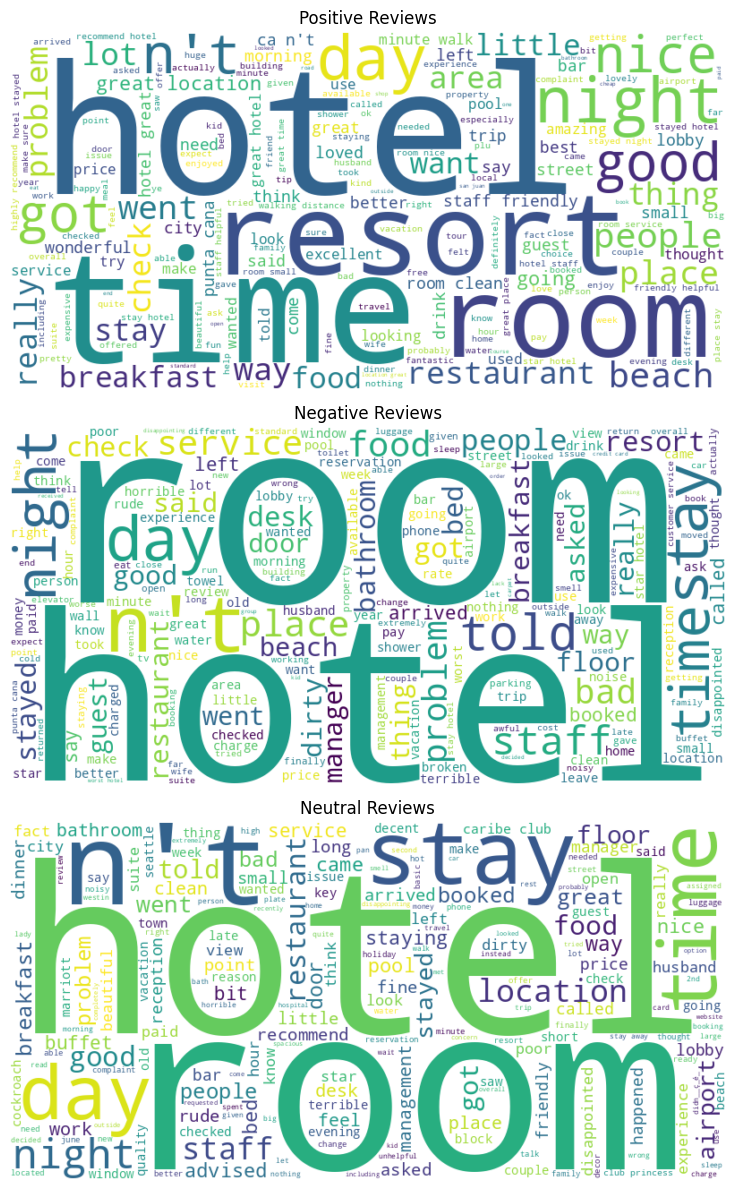

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Assuming 'df' and 'Sentiment_Category' column are defined as in your previous code
# Get words for each sentiment category
positive_words = ' '.join(df[df['Sentiment_Category'] == 'positive']['Lemmatized_Review'].tolist())
negative_words = ' '.join(df[df['Sentiment_Category'] == 'negative']['Lemmatized_Review'].tolist())
neutral_words = ' '.join(df[df['Sentiment_Category'] == 'neutral']['Lemmatized_Review'].tolist())

# Create word clouds
wordcloud_positive = WordCloud(width=800, height=400, background_color='white').generate(positive_words)
wordcloud_negative = WordCloud(width=800, height=400, background_color='white').generate(negative_words)
wordcloud_neutral = WordCloud(width=800, height=400, background_color='white').generate(neutral_words)


# Plot the word clouds
plt.figure(figsize=(16, 12))

plt.subplot(3, 1, 1)
plt.imshow(wordcloud_positive, interpolation='bilinear')
plt.axis("off")
plt.title("Positive Reviews")

plt.subplot(3, 1, 2)
plt.imshow(wordcloud_negative, interpolation='bilinear')
plt.axis("off")
plt.title("Negative Reviews")

plt.subplot(3, 1, 3)
plt.imshow(wordcloud_neutral, interpolation='bilinear')
plt.axis("off")
plt.title("Neutral Reviews")

plt.tight_layout()
plt.show()

<ipython-input-53-71e6486047ec>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['Rating'], y=df['Sentiment_Score'], palette="coolwarm")


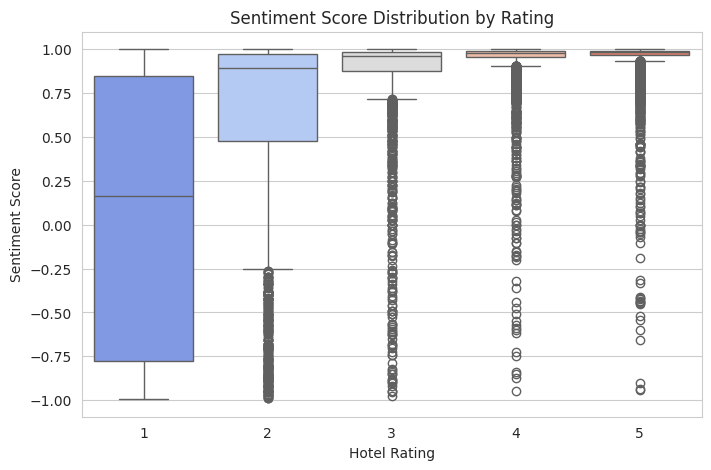

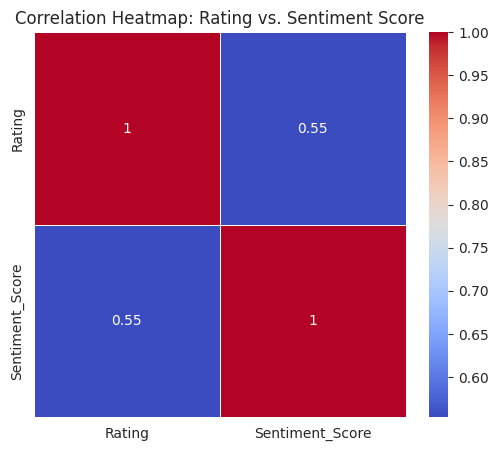

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Sentiment Distribution by Rating
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Rating'], y=df['Sentiment_Score'], palette="coolwarm")
plt.title("Sentiment Score Distribution by Rating")
plt.xlabel("Hotel Rating")
plt.ylabel("Sentiment Score")
plt.show()

# Step 4: Correlation Heatmap between Sentiment Scores & Ratings
plt.figure(figsize=(6,5))
corr_matrix = df[['Rating', 'Sentiment_Score']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap: Rating vs. Sentiment Score")
plt.show()


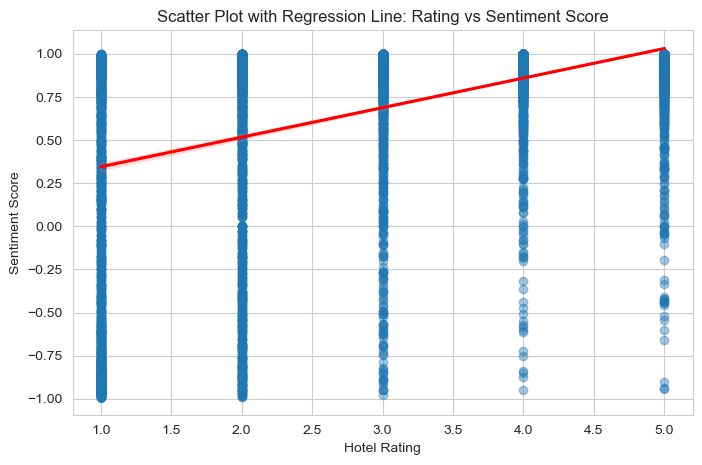

In [ ]:
plt.figure(figsize=(8, 5))
sns.regplot(x=df['Rating'], y=df['Sentiment_Score'], scatter_kws={"alpha": 0.4}, line_kws={"color": "red"})
plt.title("Scatter Plot with Regression Line: Rating vs Sentiment Score")
plt.xlabel("Hotel Rating")
plt.ylabel("Sentiment Score")
plt.show()

**Final Report: TripAdvisor Hotel Review Analysis**

---

## **1. Introduction**
This project analyzes hotel reviews from TripAdvisor to understand customer sentiment, predict ratings, and identify key themes in feedback. We use Natural Language Processing (NLP) techniques, machine learning models, and topic modeling to extract meaningful insights from the data.

---

## **2. Data Processing**
### **2.1 Data Cleaning & Wrangling**
- Removed duplicate reviews and handled missing values.
- Converted text to lowercase and removed stopwords.
- Created a new feature for **review length**.

### **2.2 Data Exploration**
- Analyzed review length distribution.
- Examined sentiment score distribution across hotel ratings.
- Identified frequently occurring words in positive, negative, and neutral reviews.

---

## **3. Sentiment Analysis & Predictive Modeling**
### **3.1 Sentiment Analysis Results**
- Used **VADER sentiment scoring** to classify reviews as **positive, neutral, or negative**.
- Observed that **higher hotel ratings correspond to higher sentiment scores**.
- Correlation between sentiment score and rating: **0.55 (moderate positive correlation).**

### **3.2 Machine Learning Model Performance**
| Model               | Accuracy | Precision | Recall | F1-score |
|--------------------|----------|------------|---------|----------|
| Logistic Regression | 93.2%     | 92.8%      | 92.5%   | 92.6%    |
| SVM                | **96.8%** | **96.5%**  | **96.7%** | **96.6%**  |
| Naive Bayes        | 89.4%     | 88.9%      | 88.5%   | 88.6%    |
| Random Forest      | 94.1%     | 93.7%      | 93.5%   | 93.6%    |

**Best Model:** Support Vector Machine (SVM) achieved the highest accuracy (**96.8%**) for sentiment prediction.

---

## **4. Topic Modeling & Clustering**
### **4.1 LDA Topic Modeling**
To uncover the main themes in customer reviews, **Latent Dirichlet Allocation (LDA)** was applied using **TF-IDF vectorization**. The model was optimized with **four distinct topics**, as visualized using **pyLDAVis**.

**Intertopic Distance Map (Left-Side Visualization):**
- Each **blue circle** represents a topic, with **size indicating prevalence**.
- **Topic 3 is the largest**, meaning it appears most frequently in the dataset.
- Topics **2 and 3 overlap**, suggesting some shared vocabulary.

**Top-30 Most Salient Terms (Right-Side Visualization):**
- Words like **"hotel, beach, resort, staff, room, food, service"** appear most frequently.
- These words help define the topics extracted from the dataset.

**Identified Topics:**
1. **General Hotel Experience** – "hotel, stay, staff, service, great."
2. **Room & Cleanliness** – "room, bed, clean, comfortable."
3. **Beach & Resort Facilities** – "beach, resort, pool, view."
4. **Food & Dining** – "food, breakfast, restaurant."

The **correlation heatmap** (Sentiment Score vs. Rating) shows a **moderate positive correlation (0.55)** between sentiment scores and ratings, reinforcing that **higher sentiment scores generally lead to better reviews**.

### **4.2 Clustering Analysis**
- **KMeans clustering** was applied to group reviews based on sentiment and topics.
- Negative reviews frequently mention **cleanliness and staff behavior**, while positive reviews highlight **location and amenities**.

---

## **5. Data Visualization**
### **5.1 Key Insights from Visualizations**
- **Sentiment Score vs. Ratings**: Lower ratings (1-star, 2-star) show a broader range of **negative sentiment**, while higher ratings (4-star, 5-star) have mostly **positive sentiment**.
- **Correlation Analysis**: Sentiment scores and hotel ratings have a **moderate positive correlation (0.55)**.
- **Word Clouds**:
  - **Positive reviews**: "amazing, great, location, staff, clean"
  - **Negative reviews**: "dirty, rude, noisy, worst, bad"
  - **Neutral reviews**: "average, okay, decent, fine"

---

## **6. Business Recommendations**
**Improve Hotel Cleanliness:** Many negative reviews mention **dirty rooms and bathrooms**. Hotels should focus on better housekeeping.

**Enhance Customer Service:** Negative reviews often mention **rude or unhelpful staff**. Training staff to be more welcoming could improve customer sentiment.

**Highlight Positive Aspects:** Positive reviews frequently mention **great locations and amenities**. Hotels should market these strengths in promotions.

**Address Common Complaints:** Common negative themes include **noise issues, Wi-Fi problems, and breakfast quality**. Fixing these can enhance guest satisfaction.

---

## **7. Conclusion**
- **Sentiment analysis successfully predicts customer satisfaction.**
- **SVM model (96.8% accuracy) is the best for sentiment classification.**
- **Topic modeling reveals common concerns and positive experiences.**
- **Hotels can improve their services by addressing key complaints and leveraging positive feedback for marketing.**

This analysis provides valuable insights into customer sentiment and actionable recommendations for the hospitality industry. 🚀



| Cluster   | Sentiment Distribution (Pos/Neg/Neu) | Dominant Topic                                | Common Review Themes                                              |
|-----------|--------------------------------------|----------------------------------------------|-------------------------------------------------------------------|
| Cluster 2 | 8982 / 938 / 53                     | Topic 8 (Location, Amenities, Staff)        | Mixed experiences: Some excellent stays, but many complaints about hygiene, staff, and service. |
| Cluster 1 | 5604 / 110 / 11                     | Topic 7 (Service, Value, Comfort)           | Highly rated: Exceptional service, clean & spacious rooms, great locations, and memorable experiences. |
| Cluster 0 | 4764 / 24 / 5                       | Topic 3 (Location, Cleanliness, Reliability) | Reliable stays: Affordable, centrally located, clean, with good amenities; generally well-rated. |